# Initialization

In [53]:
import os
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import joblib
import optuna
import json

In [54]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

In [55]:
current_dir = os.getcwd()
current_dir

'e:\\University\\OOP\\FinanceTracking\\src\\ml-service\\notebooks'

In [56]:
if current_dir.split("\\")[-1] != 'notebooks':
    target_path = os.path.join('src', 'ml-service', 'notebooks')
    os.chdir(target_path)

In [57]:
load_dotenv()

True

In [58]:
DB_URL = f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"

TEST_SIZE = 0.2 # 20%
RANDOM_STATE = 0

EXPORT_PATH = "../app/models/exports"
MODEL_EXPORT_PATH = EXPORT_PATH + "/model.joblib"
CATEGORIES_EXPORT_PATH = EXPORT_PATH + "/categories.json"

# Data loading

Here you can configure your own data loading pipeline. We'll use our own because our data is stored inside PostgreSQL DB.

This whole notebook training flow will work with any DataFrame that has columns `name` and `category`.

In [59]:
engine = create_engine(DB_URL)

In [60]:
df = pd.read_sql("SELECT * FROM products", engine)

In [61]:
df.head()

,id,name,category,preprocessed,created_at
0,202,"Нектар вишневий Наш Сік 1,93л",Напої,nektar vyshnevyj nash sik,2025-07-12 16:38:21.971804
1,6730,Цукерки Amos 4D Pineapple Burst у формі ананас...,Солодощі,tsukerky amos pineapple burst formi ananasa,2025-07-12 16:38:21.971804
2,6732,Набір подарунковий чашка 380мл з шоколадною ку...,Солодощі,nabir podarunkovyj chashka shokoladnoju kul'koju,2025-07-12 16:38:21.971804
3,6733,Цукерки Toffifee білий шоколад 125г,Солодощі,tsukerky toffifee bilyj shokolad,2025-07-12 16:38:21.971804
4,6734,Соломка Sergini Столична солодка 40г,Солодощі,solomka sergini stolychna solodka,2025-07-12 16:38:21.971804


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127853 entries, 0 to 127852
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            127853 non-null  int64         
 1   name          127853 non-null  object        
 2   category      127853 non-null  object        
 3   preprocessed  127853 non-null  object        
 4   created_at    127853 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 4.9+ MB


In [63]:
df = df[["name", "category"]]
df.head()

,name,category
0,"Нектар вишневий Наш Сік 1,93л",Напої
1,Цукерки Amos 4D Pineapple Burst у формі ананас...,Солодощі
2,Набір подарунковий чашка 380мл з шоколадною ку...,Солодощі
3,Цукерки Toffifee білий шоколад 125г,Солодощі
4,Соломка Sergini Столична солодка 40г,Солодощі


In [64]:
df.groupby("category")[["name"]].count().sort_values(by="name", ascending=False)

,name
category,
Алкоголь,13558
Товари для дому,11376
Солодощі,10479
Гігієна та догляд,10085
Одяг та взуття,6677
Товари для дітей,6553
Напої,6462
Молочні продукти,5878
М'ясо та ковбасні вироби,5770


As we can see, dataset is very imbalanced. We'll leave only the most interesting categories and group some similar categories together.

In [65]:
categories_to_group = {
    "Побутова хімія": "Гігієна та догляд",
    "Пекарня": "Кулінарія",
    "Чипси та снеки": "Кулінарія",
    "Консерви": "Кулінарія",
    "Напівфабрикати": "Кулінарія",
    "Риба та морепродукти" : "М'ясо та ковбасні вироби",
    "Жуйки" : "Солодощі"
}

df['category'] = df['category'].replace(categories_to_group)

In [66]:
categories_to_rename = {
    "Кулінарія": "Готова їжа, снеки та напівфабрикати",
    "М'ясо та ковбасні вироби": "М'ясо та риба"
}

df['category'] = df['category'].replace(categories_to_rename)

In [67]:
categories_to_leave = [
    "Алкоголь",
    "Солодощі",
    "Гігієна та догляд",
    "Одяг та взуття",
    "Напої",
    "Молочні продукти",
    "М'ясо та риба",
    "Фрукти та овочі",
    "Бакалія",
    "Готова їжа, снеки та напівфабрикати",
    "Соуси та спеції",
    "Книги",
    "Канцелярія",
    "Тютюнові вироби",
    "Електроніка",
]

df = df[df['category'].isin(categories_to_leave)].copy()

# Preprocessing

In [68]:
import re
import string
import transliterate

punctuation_to_space = string.punctuation.replace("'", "")
space_translation = str.maketrans(dict.fromkeys(punctuation_to_space, " "))
delete_translation = str.maketrans(dict.fromkeys("’«»", ""))

def normalize_ukrainian_text(text: str) -> str:
    """Processes ukrainian text string into a text string that is ready to be used inside a prediction model."""
    text = text.translate(space_translation).translate(delete_translation)
    
    res = transliterate.translit(text, language_code='uk', reversed=True)
    
    # Add spaces before capital letters (for camelCase words)
    res = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', res).lower()

    words = res.split()
    processed_words = []
    
    for word in words:
        if len(word) < 2:
            continue
            
        if any(char.isdigit() for char in word):
            continue
            
        if not re.fullmatch(r"[a-zA-Z'-]{3,40}", word):
            continue
            
        processed_words.append(word)
    
    return ' '.join(processed_words)

In [69]:
df["preprocessed"] = df["name"].apply(normalize_ukrainian_text)
df.head()

,name,category,preprocessed
0,"Нектар вишневий Наш Сік 1,93л",Напої,nektar vyshnevyj nash sik
1,Цукерки Amos 4D Pineapple Burst у формі ананас...,Солодощі,tsukerky amos pineapple burst formi ananasa
2,Набір подарунковий чашка 380мл з шоколадною ку...,Солодощі,nabir podarunkovyj chashka shokoladnoju kul'koju
3,Цукерки Toffifee білий шоколад 125г,Солодощі,tsukerky toffifee bilyj shokolad
4,Соломка Sergini Столична солодка 40г,Солодощі,solomka sergini stolychna solodka


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98143 entries, 0 to 127754
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          98143 non-null  object
 1   category      98143 non-null  object
 2   preprocessed  98143 non-null  object
dtypes: object(3)
memory usage: 3.0+ MB


In [71]:
df.groupby("category")[["name"]].count().sort_values(by="name", ascending=False)

,name
category,
Алкоголь,13558
"Готова їжа, снеки та напівфабрикати",13296
Гігієна та догляд,12802
Солодощі,10530
М'ясо та риба,8490
Одяг та взуття,6677
Напої,6462
Молочні продукти,5878
Фрукти та овочі,4747


# Train/test split

In [72]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    df['preprocessed'], 
    df['category'], 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=df['category']
)

# Model training

## Hyperparameter tuning

In [73]:
def objective(trial: optuna.Trial):
    ngram_max = trial.suggest_int("ngram_max", 2, 5)
    alpha = trial.suggest_float("alpha", 1e-10, 1.0, log=True)
    
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(1, ngram_max))),
        ('classifier', MultinomialNB(alpha=alpha))
    ])
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    
    # Using f1_macro because dataset is very imbalanced
    score = cross_val_score(
        pipeline, X_train_full, y_train_full, 
        cv=skf, n_jobs=-1, scoring='f1_macro'
    )
    return score.mean()

In [74]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-03-08 18:50:22,085] A new study created in memory with name: no-name-3c76c93b-2f01-4b5d-b108-15eab8f0e1f8


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-08 18:50:39,497] Trial 0 finished with value: 0.9059606494861606 and parameters: {'ngram_max': 4, 'alpha': 1.1325731247737054e-10}. Best is trial 0 with value: 0.9059606494861606.
[I 2026-03-08 18:50:54,934] Trial 1 finished with value: 0.9209783796061101 and parameters: {'ngram_max': 5, 'alpha': 8.948604637269194e-08}. Best is trial 1 with value: 0.9209783796061101.
[I 2026-03-08 18:51:07,030] Trial 2 finished with value: 0.8952613509609226 and parameters: {'ngram_max': 4, 'alpha': 0.2414427317100452}. Best is trial 1 with value: 0.9209783796061101.
[I 2026-03-08 18:51:17,368] Trial 3 finished with value: 0.8741766132055414 and parameters: {'ngram_max': 3, 'alpha': 5.634215989509815e-07}. Best is trial 1 with value: 0.9209783796061101.
[I 2026-03-08 18:51:24,889] Trial 4 finished with value: 0.6548949763582158 and parameters: {'ngram_max': 2, 'alpha': 0.08479046037726823}. Best is trial 1 with value: 0.9209783796061101.
[I 2026-03-08 18:51:39,637] Trial 5 finished with valu

## Final model evaluation

In [75]:
best_params = study.best_params
eval_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb', 
        ngram_range=(1, best_params['ngram_max'])
    )),
    ('classifier', MultinomialNB(alpha=best_params['alpha']))
])

In [76]:
eval_pipeline.fit(X_train_full, y_train_full)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [77]:
y_pred = eval_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

                                     precision    recall  f1-score   support

                           Алкоголь       0.99      0.98      0.98      2712
                            Бакалія       0.88      0.89      0.89       944
Готова їжа, снеки та напівфабрикати       0.91      0.81      0.86      2659
                  Гігієна та догляд       0.99      0.99      0.99      2561
                        Електроніка       0.99      0.97      0.98       114
                         Канцелярія       0.93      0.85      0.89       471
                              Книги       0.87      0.98      0.92       575
                      М'ясо та риба       0.93      0.96      0.95      1698
                   Молочні продукти       0.96      0.95      0.96      1176
                              Напої       0.93      0.97      0.95      1292
                     Одяг та взуття       1.00      0.99      1.00      1335
                           Солодощі       0.90      0.96      0.93      210

Our results satisfy us, so we'll proceed to final stages.

# Finding confidence threshold

In [78]:
import numpy as np
import matplotlib.pyplot as plt

probs = eval_pipeline.predict_proba(X_test)
confidences = probs.max(axis=1)
predicted_classes = eval_pipeline.classes_[probs.argmax(axis=1)]
correct = (predicted_classes == y_test.values)

print(f"Confidence distribution:")
print(f"  min={confidences.min():.3f}, mean={confidences.mean():.3f}, "
      f"median={np.median(confidences):.3f}, max={confidences.max():.3f}")
print()

thresholds = np.arange(0.10, 0.96, 0.05)
results = []

for t in thresholds:
    mask = confidences >= t
    n_covered = mask.sum()
    if n_covered == 0:
        break
    acc = correct[mask].mean()
    coverage = n_covered / len(confidences)
    results.append((t, acc, coverage, n_covered))
    print(f"threshold={t:.2f}  accuracy={acc:.3f}  coverage={coverage:.3f}  ({n_covered}/{len(confidences)} samples)")

Confidence distribution:
  min=0.298, mean=0.981, median=1.000, max=1.000

threshold=0.10  accuracy=0.936  coverage=1.000  (19629/19629 samples)
threshold=0.15  accuracy=0.936  coverage=1.000  (19629/19629 samples)
threshold=0.20  accuracy=0.936  coverage=1.000  (19629/19629 samples)
threshold=0.25  accuracy=0.936  coverage=1.000  (19629/19629 samples)
threshold=0.30  accuracy=0.936  coverage=1.000  (19628/19629 samples)
threshold=0.35  accuracy=0.936  coverage=1.000  (19621/19629 samples)
threshold=0.40  accuracy=0.937  coverage=0.999  (19609/19629 samples)
threshold=0.45  accuracy=0.937  coverage=0.998  (19592/19629 samples)
threshold=0.50  accuracy=0.938  coverage=0.997  (19561/19629 samples)
threshold=0.55  accuracy=0.941  coverage=0.991  (19459/19629 samples)
threshold=0.60  accuracy=0.943  coverage=0.986  (19357/19629 samples)
threshold=0.65  accuracy=0.946  coverage=0.980  (19242/19629 samples)
threshold=0.70  accuracy=0.948  coverage=0.974  (19126/19629 samples)
threshold=0.75 

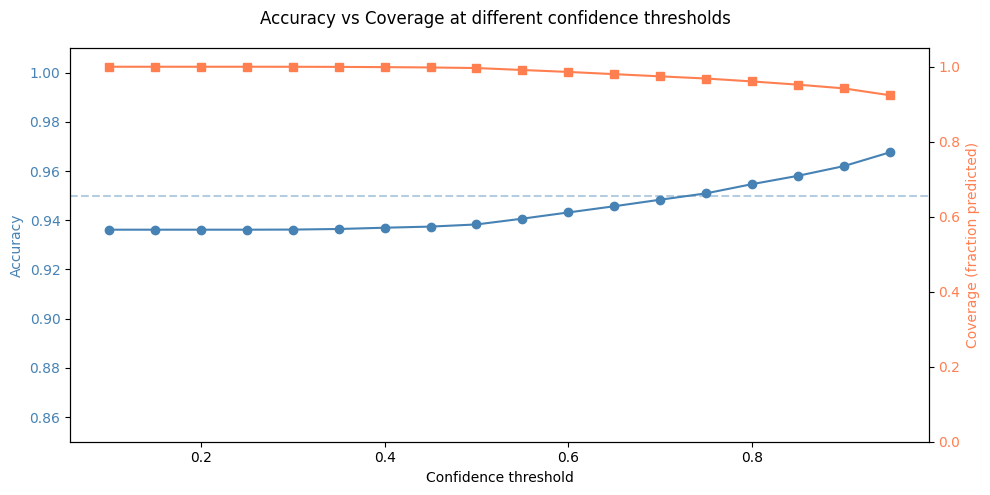

In [79]:
thresholds_plot = [r[0] for r in results]
accuracies = [r[1] for r in results]
coverages = [r[2] for r in results]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel("Confidence threshold")
ax1.set_ylabel("Accuracy", color="steelblue")
ax1.plot(thresholds_plot, accuracies, color="steelblue", marker="o", label="Accuracy")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.axhline(0.95, color="steelblue", linestyle="--", alpha=0.4, label="95% accuracy target")
ax1.set_ylim(0.85, 1.01)

ax2 = ax1.twinx()
ax2.set_ylabel("Coverage (fraction predicted)", color="coral")
ax2.plot(thresholds_plot, coverages, color="coral", marker="s", label="Coverage")
ax2.tick_params(axis="y", labelcolor="coral")
ax2.set_ylim(0, 1.05)

fig.suptitle("Accuracy vs Coverage at different confidence thresholds")
fig.tight_layout()
plt.show()

As we can see, our accuracy crosses 95% only after around 0.7+ threshold. We'll go with 0.75 threshold for this model in production due to the fact that it still has 0.969 coverage which should be enough.

# Final training

In [80]:
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb', 
        ngram_range=(1, best_params['ngram_max'])
    )),
    ('classifier', MultinomialNB(alpha=best_params['alpha']))
])

In [81]:
final_pipeline.fit(df['preprocessed'], df['category'])

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


# Exporting

In [82]:
joblib.dump(final_pipeline, MODEL_EXPORT_PATH)

['../app/models/exports/model.joblib']

In [83]:
with open(CATEGORIES_EXPORT_PATH, 'w', encoding='utf-8') as f:
    json.dump(categories_to_leave, f, ensure_ascii=False, indent=4)